In [32]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt



df = pd.read_csv('kc_house_data.csv')

df.sample(5)
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [33]:
print('Existen ', df.isnull().sum().sum(),' valores no existentes')

Existen  2  valores no existentes


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4580301520.9,2876565571.3,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0
price,21613.0,540088.1,367127.2,75000.0,321950.0,450000.0,645000.0,7700000.0
bedrooms,21613.0,3.4,0.9,0.0,3.0,3.0,4.0,33.0
bathrooms,21613.0,2.1,0.8,0.0,1.8,2.2,2.5,8.0
sqft_living,21613.0,2079.9,918.4,290.0,1427.0,1910.0,2550.0,13540.0
sqft_lot,21613.0,15107.0,41420.5,520.0,5040.0,7618.0,10688.0,1651359.0
floors,21613.0,1.5,0.5,1.0,1.0,1.5,2.0,3.5
waterfront,21613.0,0.0,0.1,0.0,0.0,0.0,0.0,1.0
view,21613.0,0.2,0.8,0.0,0.0,0.0,0.0,4.0
condition,21613.0,3.4,0.7,1.0,3.0,3.0,4.0,5.0


In [36]:
pd.set_option('display.float_format',lambda x:'%.1f'%x)

In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4580301520.9,2876565571.3,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0
price,21613.0,540088.1,367127.2,75000.0,321950.0,450000.0,645000.0,7700000.0
bedrooms,21613.0,3.4,0.9,0.0,3.0,3.0,4.0,33.0
bathrooms,21613.0,2.1,0.8,0.0,1.8,2.2,2.5,8.0
sqft_living,21613.0,2079.9,918.4,290.0,1427.0,1910.0,2550.0,13540.0
sqft_lot,21613.0,15107.0,41420.5,520.0,5040.0,7618.0,10688.0,1651359.0
floors,21613.0,1.5,0.5,1.0,1.0,1.5,2.0,3.5
waterfront,21613.0,0.0,0.1,0.0,0.0,0.0,0.0,1.0
view,21613.0,0.2,0.8,0.0,0.0,0.0,0.0,4.0
condition,21613.0,3.4,0.7,1.0,3.0,3.0,4.0,5.0


In [38]:
df.nunique()

id               21436
date               372
price             4028
bedrooms            13
bathrooms           30
sqft_living       1038
sqft_lot          9782
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         946
sqft_basement      306
yr_built           116
yr_renovated        70
zipcode             70
lat               5034
long               752
sqft_living15      777
sqft_lot15        8689
dtype: int64

In [39]:
#df['mainroad'] = df['mainroad'].replace({'yes':1,'no':0},regex=True)

In [40]:
df.head(20)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.0,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5,-122.3,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.2,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7,-122.3,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.0,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7,-122.2,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.0,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5,-122.4,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.0,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6,-122.0,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.5,5420,101930,1.0,0,0,...,11,3890.0,1530,2001,0,98053,47.7,-122.0,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.2,1715,6819,2.0,0,0,...,7,1715.0,0,1995,0,98003,47.3,-122.3,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.5,1060,9711,1.0,0,0,...,7,1060.0,0,1963,0,98198,47.4,-122.3,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.0,1780,7470,1.0,0,0,...,7,1050.0,730,1960,0,98146,47.5,-122.3,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.5,1890,6560,2.0,0,0,...,7,1890.0,0,2003,0,98038,47.4,-122.0,2390,7570


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [42]:
df['id'] = df['id'].astype(str)

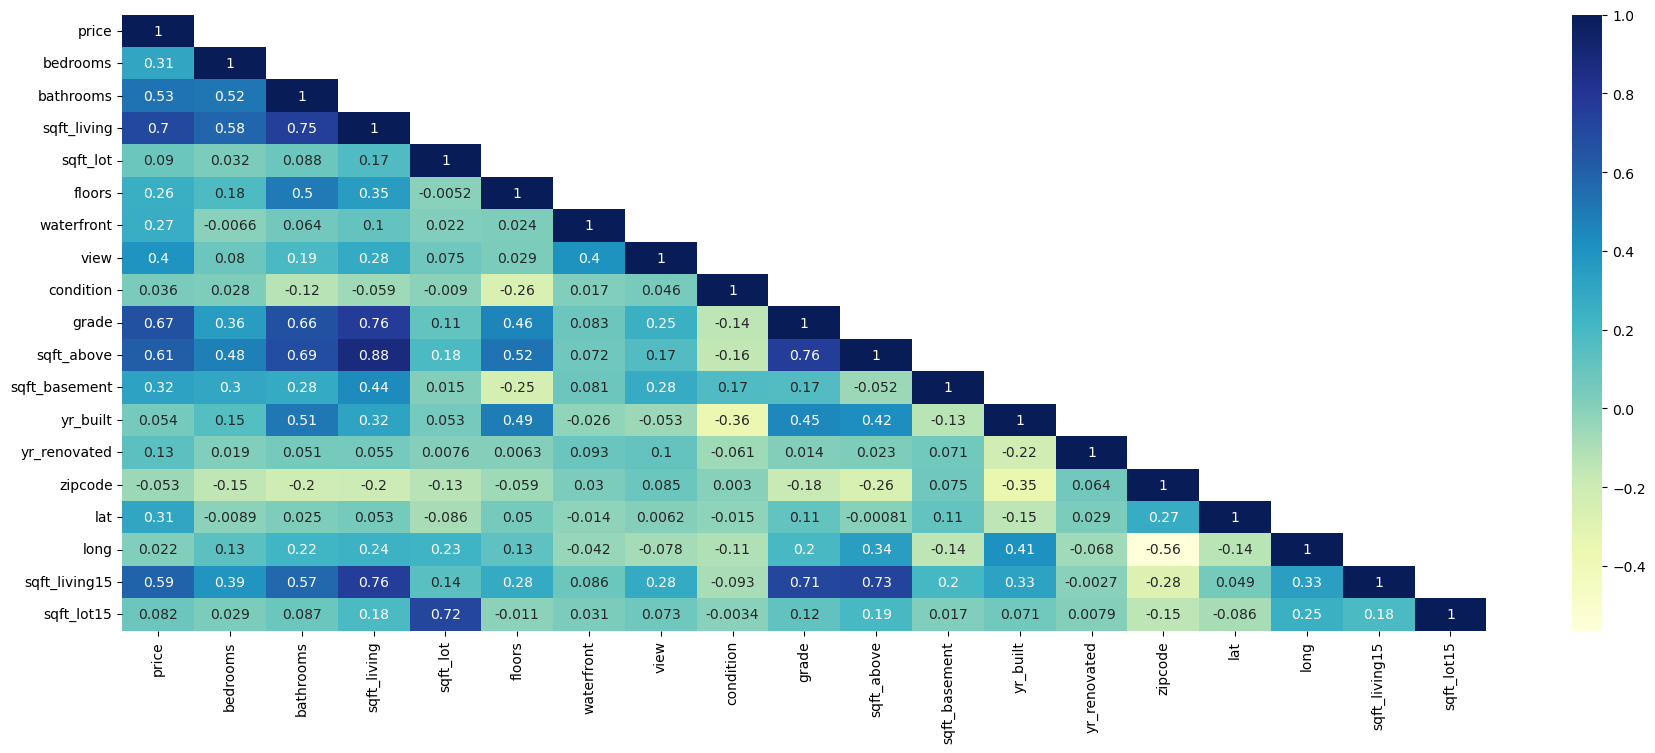

In [43]:
plt.figure(figsize=(22,8))
corr_df = corr = df.corr(method='pearson',numeric_only=True)
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap=sns.heatmap(df_lt, cmap='YlGnBu',annot=True)

In [44]:
print('Lista completa de columnas')
print('---------------------------------------------------------------------------')
print(df.columns)
print(len(df.columns),' columnas')

cols_num = [ 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15']

Lista completa de columnas
---------------------------------------------------------------------------
Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')
21  columnas


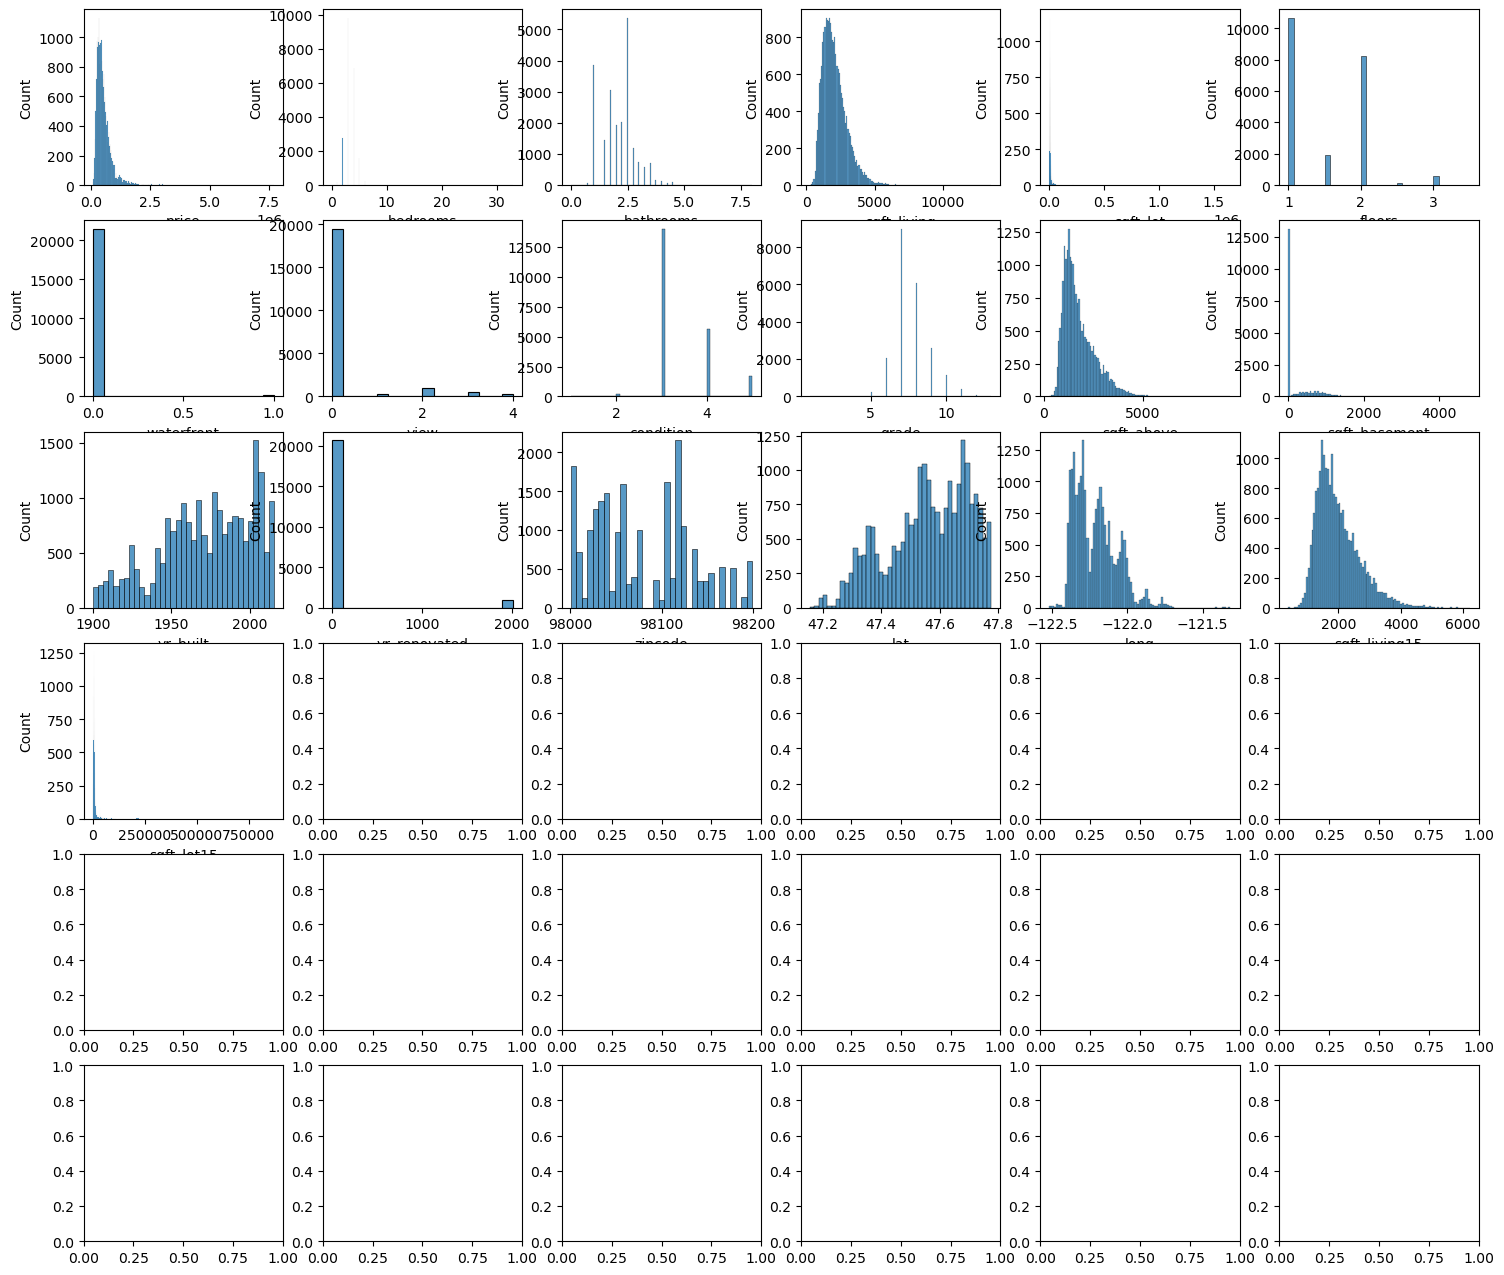

In [45]:
fig, axes = plt.subplots(nrows = 6 ,ncols=6, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//6,i%6],kde=False)

In [46]:
df.groupby('bedrooms').mean(numeric_only=True).T

bedrooms,0,1,2,3,4,5,6,7,8,9,10,11,33
price,409503.8,317642.9,401372.7,466232.1,635419.5,786599.8,825520.6,951184.7,1105076.9,893999.8,819333.3,520000.0,640000.0
bathrooms,0.8,1.1,1.4,2.0,2.4,2.8,3.1,3.7,3.6,4.4,3.4,3.0,1.8
sqft_living,1707.8,884.6,1239.8,1805.8,2554.6,3047.5,3284.3,3974.2,3800.0,3775.0,3706.7,3000.0,1620.0
sqft_lot,24141.3,16285.7,12096.7,14414.8,16720.8,16769.0,18586.9,20840.6,8971.6,5480.0,8859.7,4960.0,6000.0
floors,2.0,1.2,1.3,1.4,1.6,1.6,1.6,1.7,1.7,2.2,1.7,2.0,1.0
waterfront,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
view,0.3,0.2,0.2,0.2,0.3,0.4,0.5,0.5,0.2,0.0,0.7,0.0,0.0
condition,2.8,3.3,3.4,3.4,3.4,3.4,3.5,3.4,3.5,3.0,3.7,3.0,5.0
grade,6.7,6.1,6.9,7.5,8.1,8.3,8.1,8.4,8.1,7.8,7.7,7.0,7.0
sqft_above,1707.8,823.9,1107.2,1584.4,2198.4,2407.6,2494.4,3160.3,2660.8,2935.0,2456.7,2400.0,1040.0


In [47]:
df.groupby('bedrooms').median(numeric_only=True).T

bedrooms,0,1,2,3,4,5,6,7,8,9,10,11,33
price,288000.0,299000.0,374000.0,413000.0,549997.5,620000.0,650000.0,728580.0,700000.0,817000.0,660000.0,520000.0,640000.0
bathrooms,0.0,1.0,1.0,2.0,2.5,2.8,3.0,3.5,3.2,4.2,3.0,3.0,1.8
sqft_living,1470.0,780.0,1140.0,1680.0,2410.0,2870.0,2955.0,3335.0,3840.0,3755.0,3610.0,3000.0,1620.0
sqft_lot,5900.0,5750.0,5244.0,7629.5,8100.0,8925.0,8696.0,8836.0,7500.0,5254.0,10920.0,4960.0,6000.0
floors,2.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0
waterfront,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
view,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
condition,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,5.0
grade,7.0,6.0,7.0,7.0,8.0,8.0,8.0,8.0,8.0,7.0,7.0,7.0,7.0
sqft_above,1470.0,760.0,1010.0,1440.0,2080.0,2190.0,2340.0,2820.0,2530.0,2680.0,2500.0,2400.0,1040.0


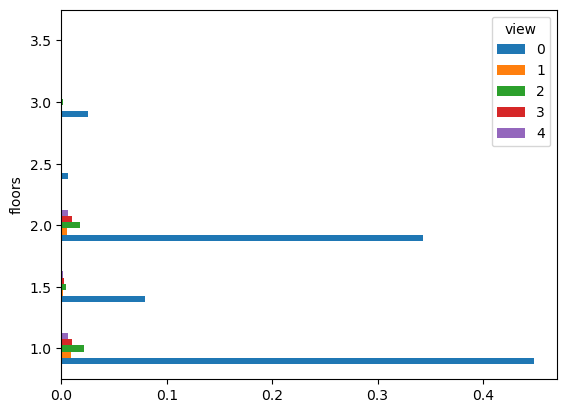

In [48]:
ct = pd.crosstab(df['floors'],df['view'],normalize=True).plot.barh(stacked=False)

In [49]:
df.corr( numeric_only=True).style.background_gradient(cmap = 'Blues').set_properties(**{'front_size':'10px'})

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
price,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477616,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685363,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876644,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183511,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523899,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072074,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167648,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158206,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406
grade,0.667434,0.356967,0.664983,0.762704,0.113621,0.458183,0.082775,0.251321,-0.144674,1.000000,0.755924,0.168392,0.446963,0.014414,-0.184862,0.114084,0.198372,0.713202,0.119248


# Modelo de regresión

In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [62]:
df = df.dropna()
X = df.drop(['price','id','date'],axis=1)
y = df[['price']]

In [63]:
y.head()

,price
0,221900.0
1,538000.0
2,180000.0
3,604000.0
4,510000.0


In [64]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

In [65]:
X_train.head(3)

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
2062,5,2.0,1380,4300,1.5,0,0,3,7,1380.0,0,1916,0,98103,47.7,-122.3,1830,3800
20522,4,2.8,2700,7992,2.0,0,0,3,9,2700.0,0,2012,0,98059,47.5,-122.1,2840,7992
8276,3,1.0,1210,5750,1.5,0,0,4,7,1210.0,0,1910,0,98136,47.5,-122.4,1160,5000


In [66]:
regression_model = LinearRegression()

regression_model.fit(X_train,y_train)

LinearRegression()

In [67]:
regression_model.score(X_train,y_train)

0.6925551342240801

In [68]:
regression_model.score(X_test,y_test)

0.7153962762729047

In [70]:
y_pred = regression_model.predict(X_test)

In [71]:
df_preds = pd.DataFrame({'Actual':y_test.squeeze(),'Predicted':y_pred.squeeze()})
print(df_preds)

        Actual  Predicted
15544 459000.0   640456.6
18932 465000.0   582906.6
20187 462550.0   397489.3
3429  475000.0   638411.5
8811  750000.0   566099.6
...        ...        ...
14866 394500.0   567704.8
4905  186000.0   137204.3
17968 260000.0   530157.0
14320 495000.0   505001.0
18802 293000.0   743340.5

[6484 rows x 2 columns]


In [72]:
y_test

,price
15544,459000.0
18932,465000.0
20187,462550.0
3429,475000.0
8811,750000.0
...,...
14866,394500.0
4905,186000.0
17968,260000.0
14320,495000.0


In [73]:
y_pred

array([[640456.55877046],
       [582906.56575882],
       [397489.26809531],
       ...,
       [530157.04271694],
       [505000.97485793],
       [743340.52302195]])

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = regression_model.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

In [78]:
print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squared error: {mse:.2f}')
print(f'Root mean squared error: {rmse:.2f}')

Mean absolute error: 125143.41
Mean squared error: 39194042530.06
Root mean squared error: 197974.85


In [79]:
for idx, col_name in enumerate(X_train.columns):
    print('Coef {} = {}'.format(col_name,regression_model.coef_[0][idx]))

Coef bedrooms = -33978.63425259125
Coef bathrooms = 40061.340350459286
Coef sqft_living = 111.6528740710028
Coef sqft_lot = 0.167077578244191
Coef floors = 7293.711637457003
Coef waterfront = 592965.9271749031
Coef view = 48211.25625545934
Coef condition = 24821.57540913914
Coef grade = 94490.1185108453
Coef sqft_above = 69.62097703972101
Coef sqft_basement = 42.03189690614173
Coef yr_built = -2604.2350279937687
Coef yr_renovated = 21.3716567006679
Coef zipcode = -578.2018438165866
Coef lat = 608405.2653193751
Coef long = -221890.3683473496
Coef sqft_living15 = 21.388750631858287
Coef sqft_lot15 = -0.3524190567442172


In [82]:
coeff_data = pd.DataFrame({
    'Var': ['Intercept'] + list(X_train.columns),
    'Coeff': [regression_model.intercept_[0]] + list(regression_model.coef_[0])
})

coeff_data

,Var,Coeff
0,Intercept,5110776.2
1,bedrooms,-33978.6
2,bathrooms,40061.3
3,sqft_living,111.7
4,sqft_lot,0.2
5,floors,7293.7
6,waterfront,592965.9
7,view,48211.3
8,condition,24821.6
9,grade,94490.1


In [84]:
Equation = 'Price = '
print(Equation, end='')

for i in range(len(coeff_data)):
    coeff = coeff_data.iloc[i]['Coeff']
    var = coeff_data.iloc[i]['Var']

    if i < len(coeff_data) - 1:
        print(f'({coeff}) * {var} + ', end='')
    else:
        print(f'({coeff}) * {var}')

Price = (5110776.215425472) * Intercept + (-33978.63425259125) * bedrooms + (40061.340350459286) * bathrooms + (111.6528740710028) * sqft_living + (0.167077578244191) * sqft_lot + (7293.711637457003) * floors + (592965.9271749031) * waterfront + (48211.25625545934) * view + (24821.57540913914) * condition + (94490.1185108453) * grade + (69.62097703972101) * sqft_above + (42.03189690614173) * sqft_basement + (-2604.2350279937687) * yr_built + (21.3716567006679) * yr_renovated + (-578.2018438165866) * zipcode + (608405.2653193751) * lat + (-221890.3683473496) * long + (21.388750631858287) * sqft_living15 + (-0.3524190567442172) * sqft_lot15


Text(0.5, 1.0, 'Comparación de Predicción (x) vs Real (y)')

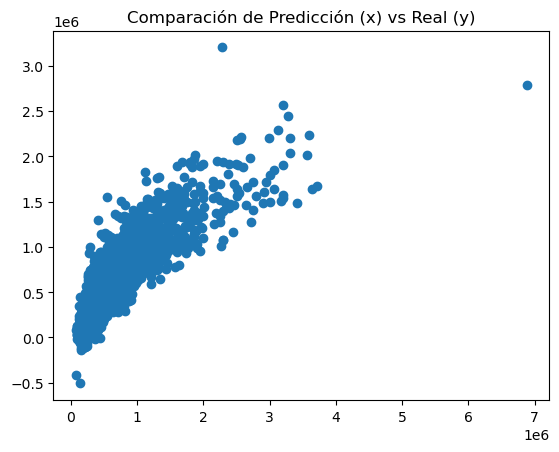

In [85]:
predictions = regression_model.predict(X_test)
plt.scatter(y_test,predictions)
plt.title('Comparación de Predicción (x) vs Real (y)')

Text(0.5, 1.0, 'Residuals')

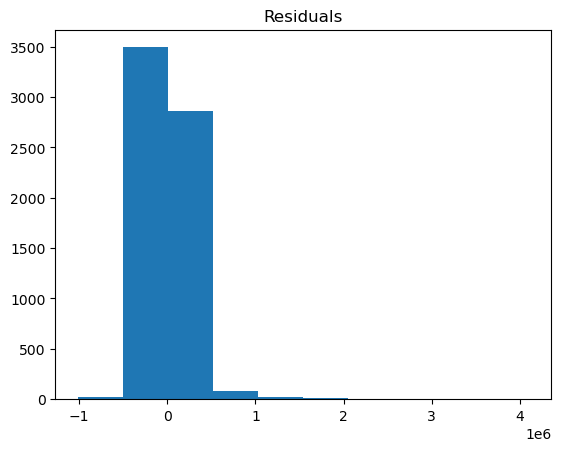

In [86]:
plt.hist(y_test - predictions)
plt.title('Residuals')

In [87]:
df.sample(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
18246,4025300360,20150326T000000,349500.0,3,2.0,1130,16875,1.0,0,0,...,7,1130.0,0,1947,0,98155,47.7,-122.3,1600,14300
7512,1154100515,20140926T000000,470000.0,3,2.8,2770,54707,1.5,0,0,...,8,2370.0,400,1938,0,98155,47.8,-122.3,1640,54707
4535,5556300076,20150423T000000,1442500.0,3,2.2,2630,9705,2.5,0,2,...,8,2630.0,0,1987,0,98052,47.6,-122.1,2640,14284
1215,2095800400,20141113T000000,455000.0,3,2.5,2090,8653,2.0,0,0,...,8,2090.0,0,1989,0,98011,47.7,-122.2,2090,6396
18674,7437100770,20140521T000000,275000.0,3,2.5,2030,6326,2.0,0,0,...,7,2030.0,0,1993,0,98038,47.3,-122.0,1810,6825
7329,203101330,20140701T000000,485000.0,3,2.2,2440,47916,2.0,0,0,...,8,2090.0,350,1991,0,98053,47.6,-122.0,2150,24000
2818,5035300850,20141110T000000,1385000.0,5,3.8,3290,6480,2.0,0,0,...,10,2190.0,1100,1938,0,98199,47.7,-122.4,2010,7639
15024,6646200420,20150102T000000,633000.0,4,2.5,2020,8044,2.0,0,0,...,8,2020.0,0,1990,0,98074,47.6,-122.0,2320,7328
9472,8682262720,20150310T000000,495000.0,2,2.0,1580,5203,1.0,0,0,...,8,1580.0,0,2004,0,98053,47.7,-122.0,1560,4770
3859,1891100090,20140505T000000,620000.0,3,1.8,1480,2185,2.5,0,0,...,9,1480.0,0,2005,0,98034,47.7,-122.2,1480,2441


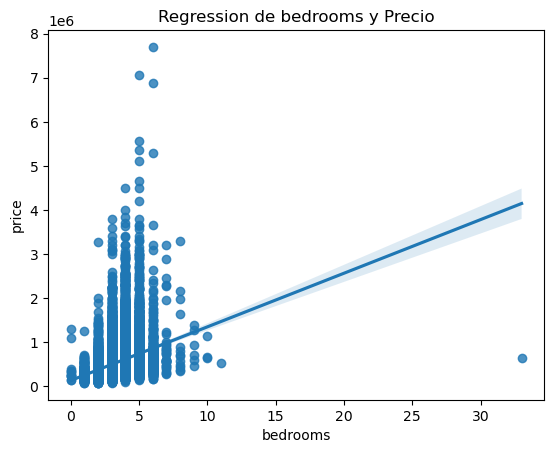

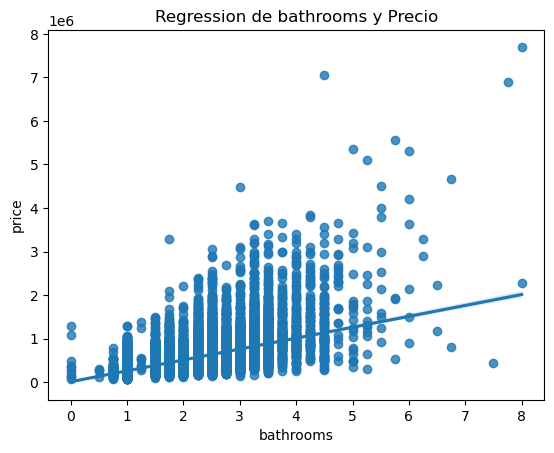

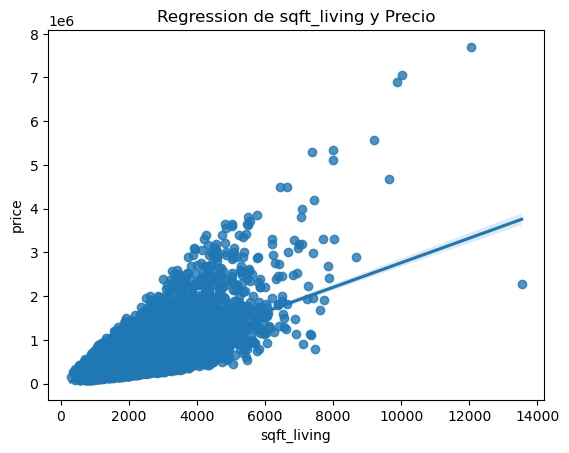

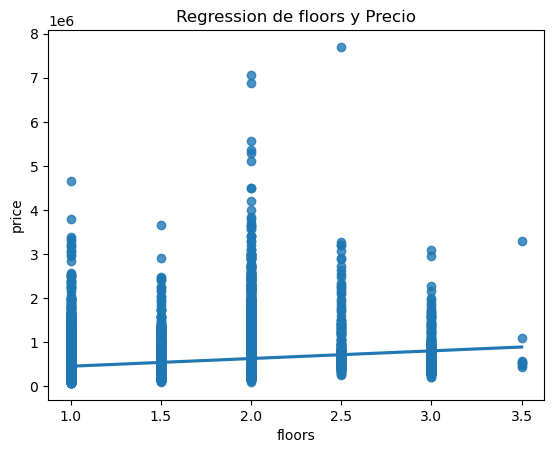

In [89]:
import seaborn as sns

variables = ['bedrooms','bathrooms','sqft_living','floors']

for var in variables:
    plt.figure()
    sns.regplot(x=var,y='price',data=df).set(title=f'Regression de {var} y Precio')

In [93]:
y_pred_df = pd.DataFrame(y_pred,columns = ['pred_price'])

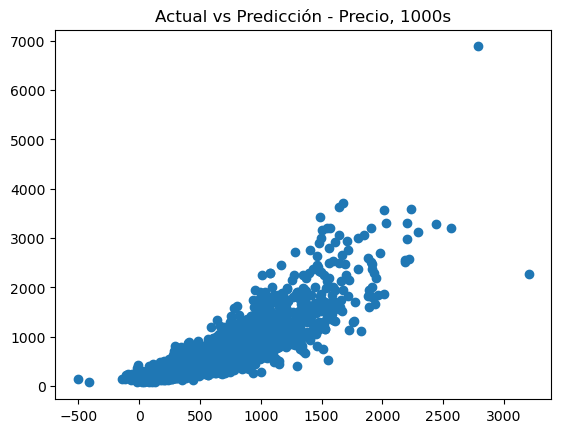

In [95]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.ticklabel_format(style='plain')
plt.title('Actual vs Predicción - Precio, 1000s')
plt.scatter(y_pred_df.pred_price/1000, y_test.price/1000)

In [96]:
import numpy as np

import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, r2_score



In [99]:
# Imputación de valores faltantes

imputer = SimpleImputer(strategy='mean')

#df['X'] = imputer.fit_transform(df[['X']])

# Estandarización de los datos

scaler = StandardScaler()

#df['X'] = scaler.fit_transform(df[['X']])

In [101]:
#X = df[['X']] # Variable independiente

#y = df['y']  # Variable dependiente

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [102]:
model = LinearRegression()

model.fit(X_train, y_train)



LinearRegression()

In [103]:
# Coeficiente y ordenada al origen

print("Pendiente (coeficiente):", model.coef_[0])

print("Intercepción (ordenada al origen):", model.intercept_)

Pendiente (coeficiente): [-3.39786343e+04  4.00613404e+04  1.11652874e+02  1.67077578e-01
  7.29371164e+03  5.92965927e+05  4.82112563e+04  2.48215754e+04
  9.44901185e+04  6.96209770e+01  4.20318969e+01 -2.60423503e+03
  2.13716567e+01 -5.78201844e+02  6.08405265e+05 -2.21890368e+05
  2.13887506e+01 -3.52419057e-01]
Intercepción (ordenada al origen): [5110776.21542547]


In [104]:
y_pred = model.predict(X_test)

# Evaluación del modelo

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Error Cuadrático Medio (MSE):", mse)

print("R cuadrado:", r2)

Error Cuadrático Medio (MSE): 39194042530.05674
R cuadrado: 0.7153962762729047
